In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
import tensorflow as tf
from sklearn.model_selection import train_test_split

In [16]:
import pylab
from pylab import rcParams

In [17]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.5)
rcParams['figure.figsize'] = 16, 10
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [18]:
df = pd.read_csv("/Users/amogh/Price-Prediction/AB_NYC_2019.csv")
df.head(5)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## Data Exploration

In [19]:
df.shape

(48895, 16)

/var/folders/sq/tx7yrpx14j9ff8_clmn3gd6w0000gn/T/ipykernel_1485/2239777731.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.price)


<Axes: xlabel='price', ylabel='Density'>

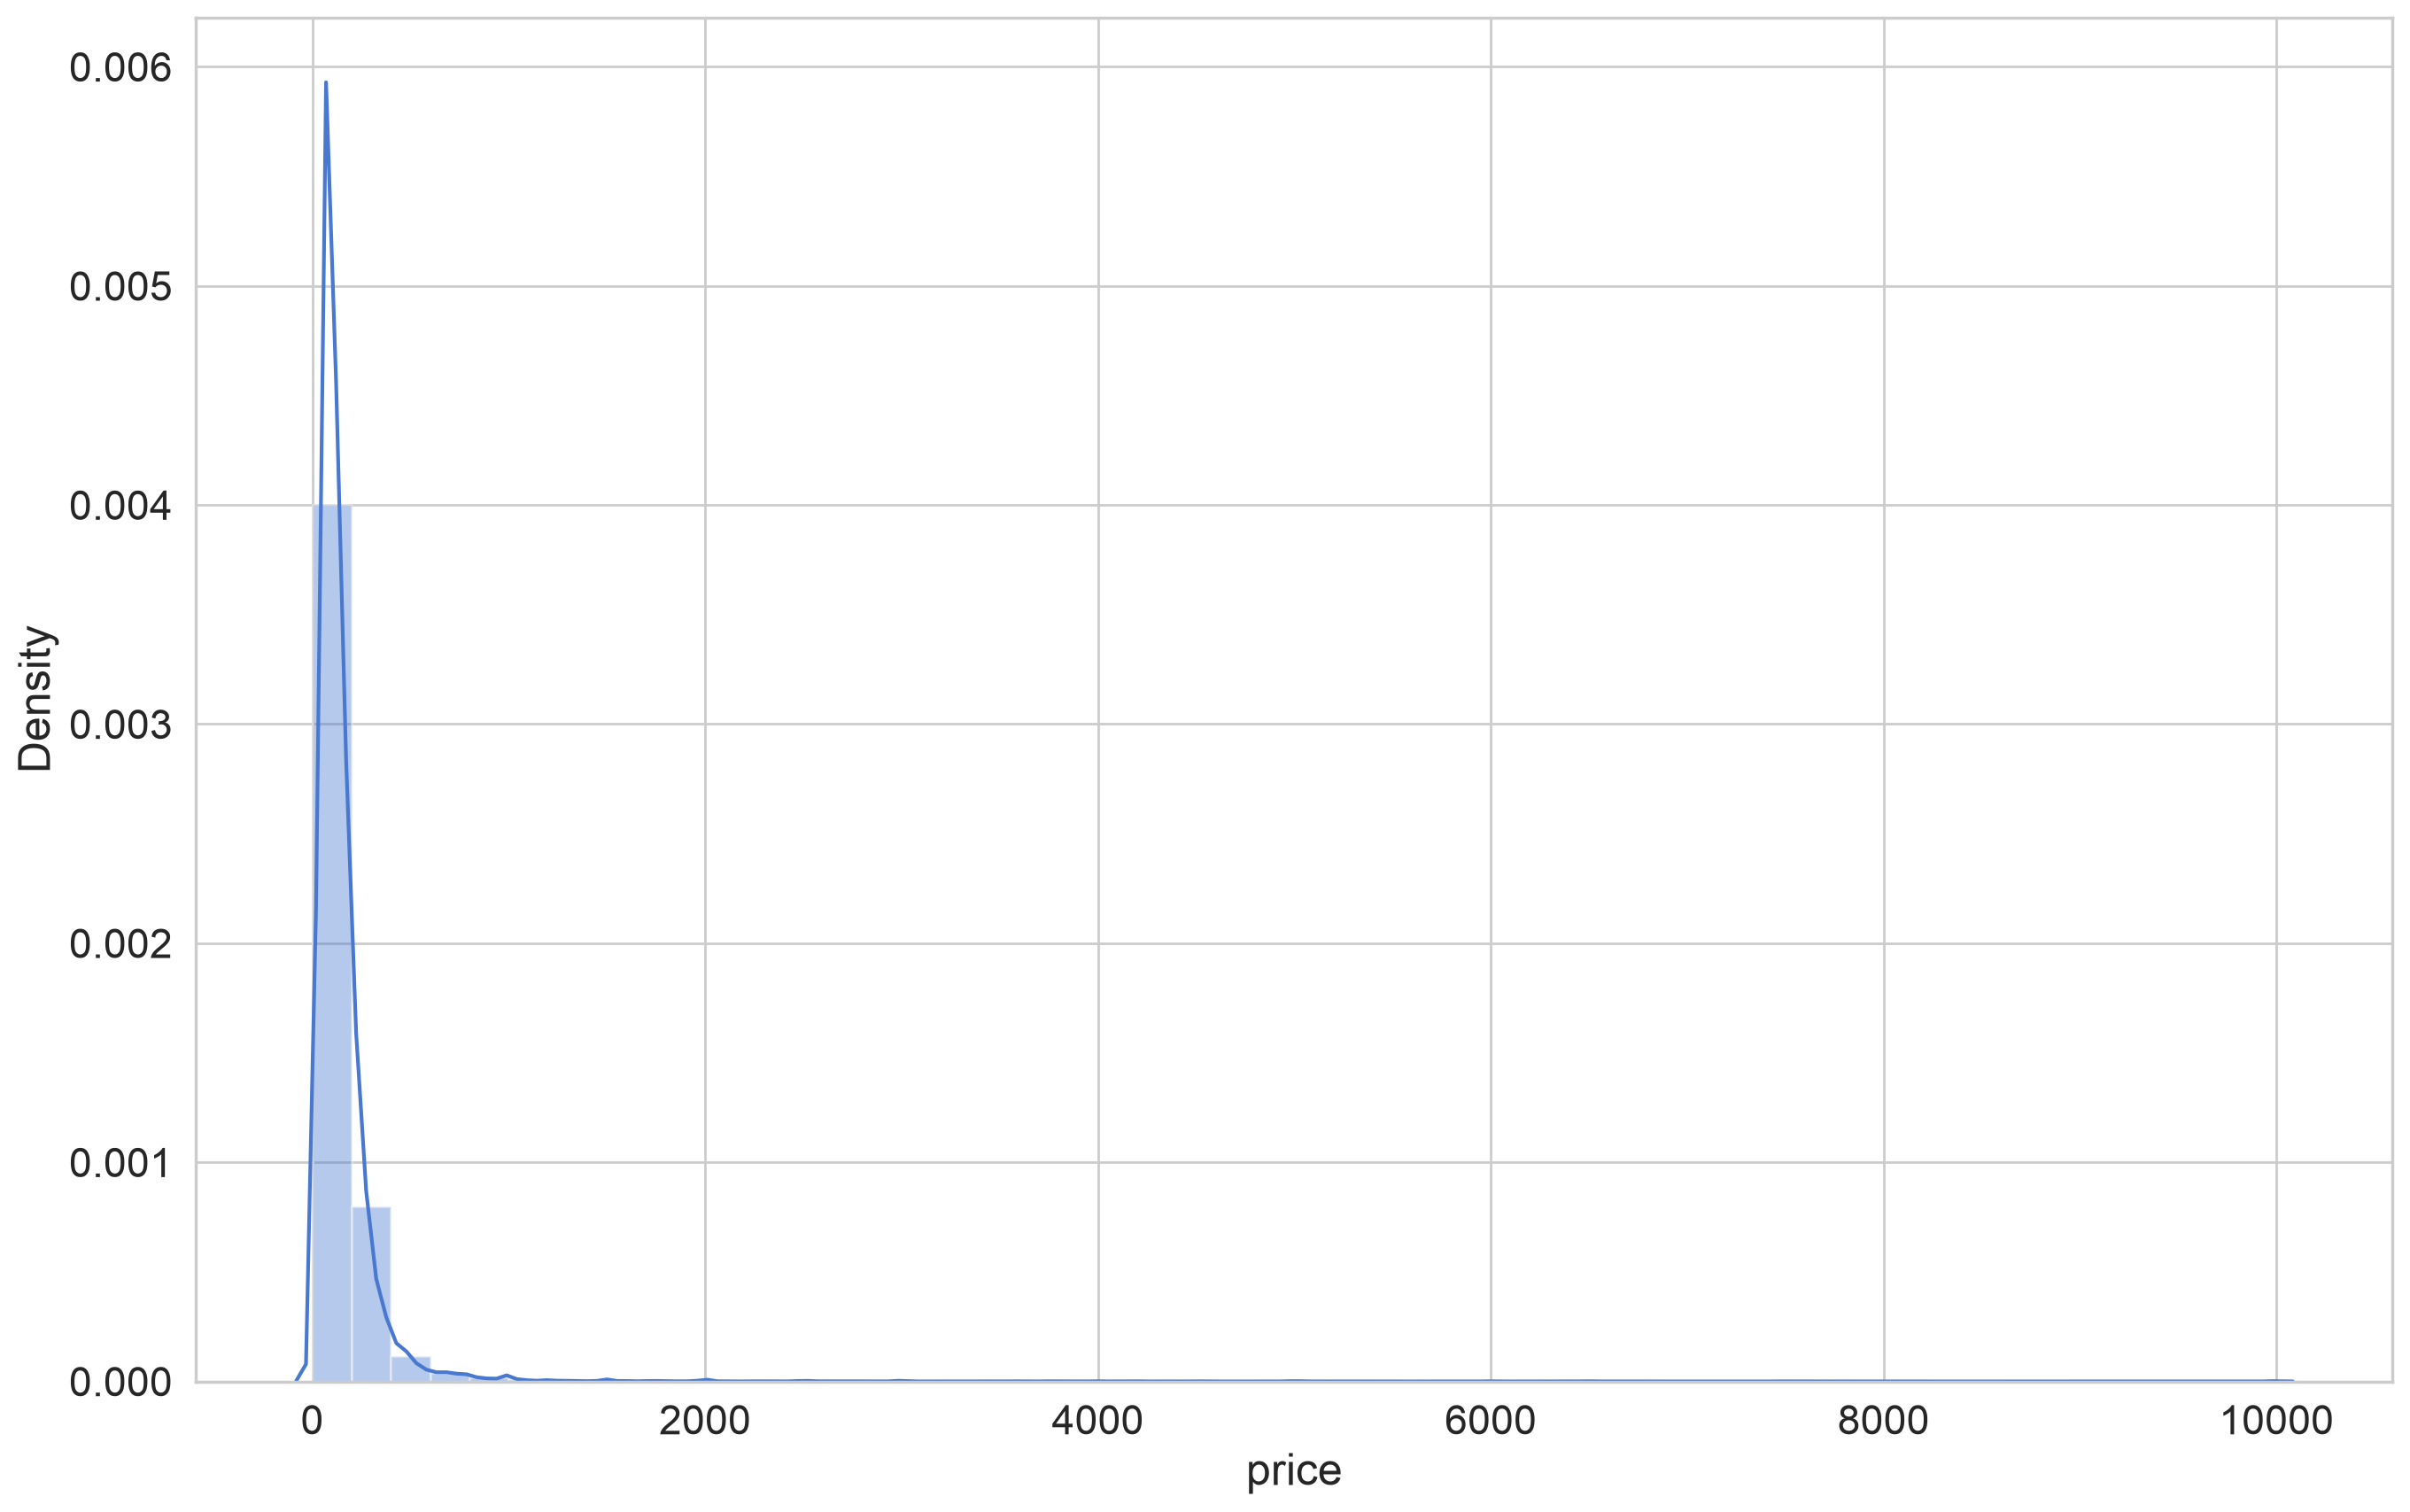

In [20]:
sns.distplot(df.price)

<Axes: xlabel='price', ylabel='Count'>

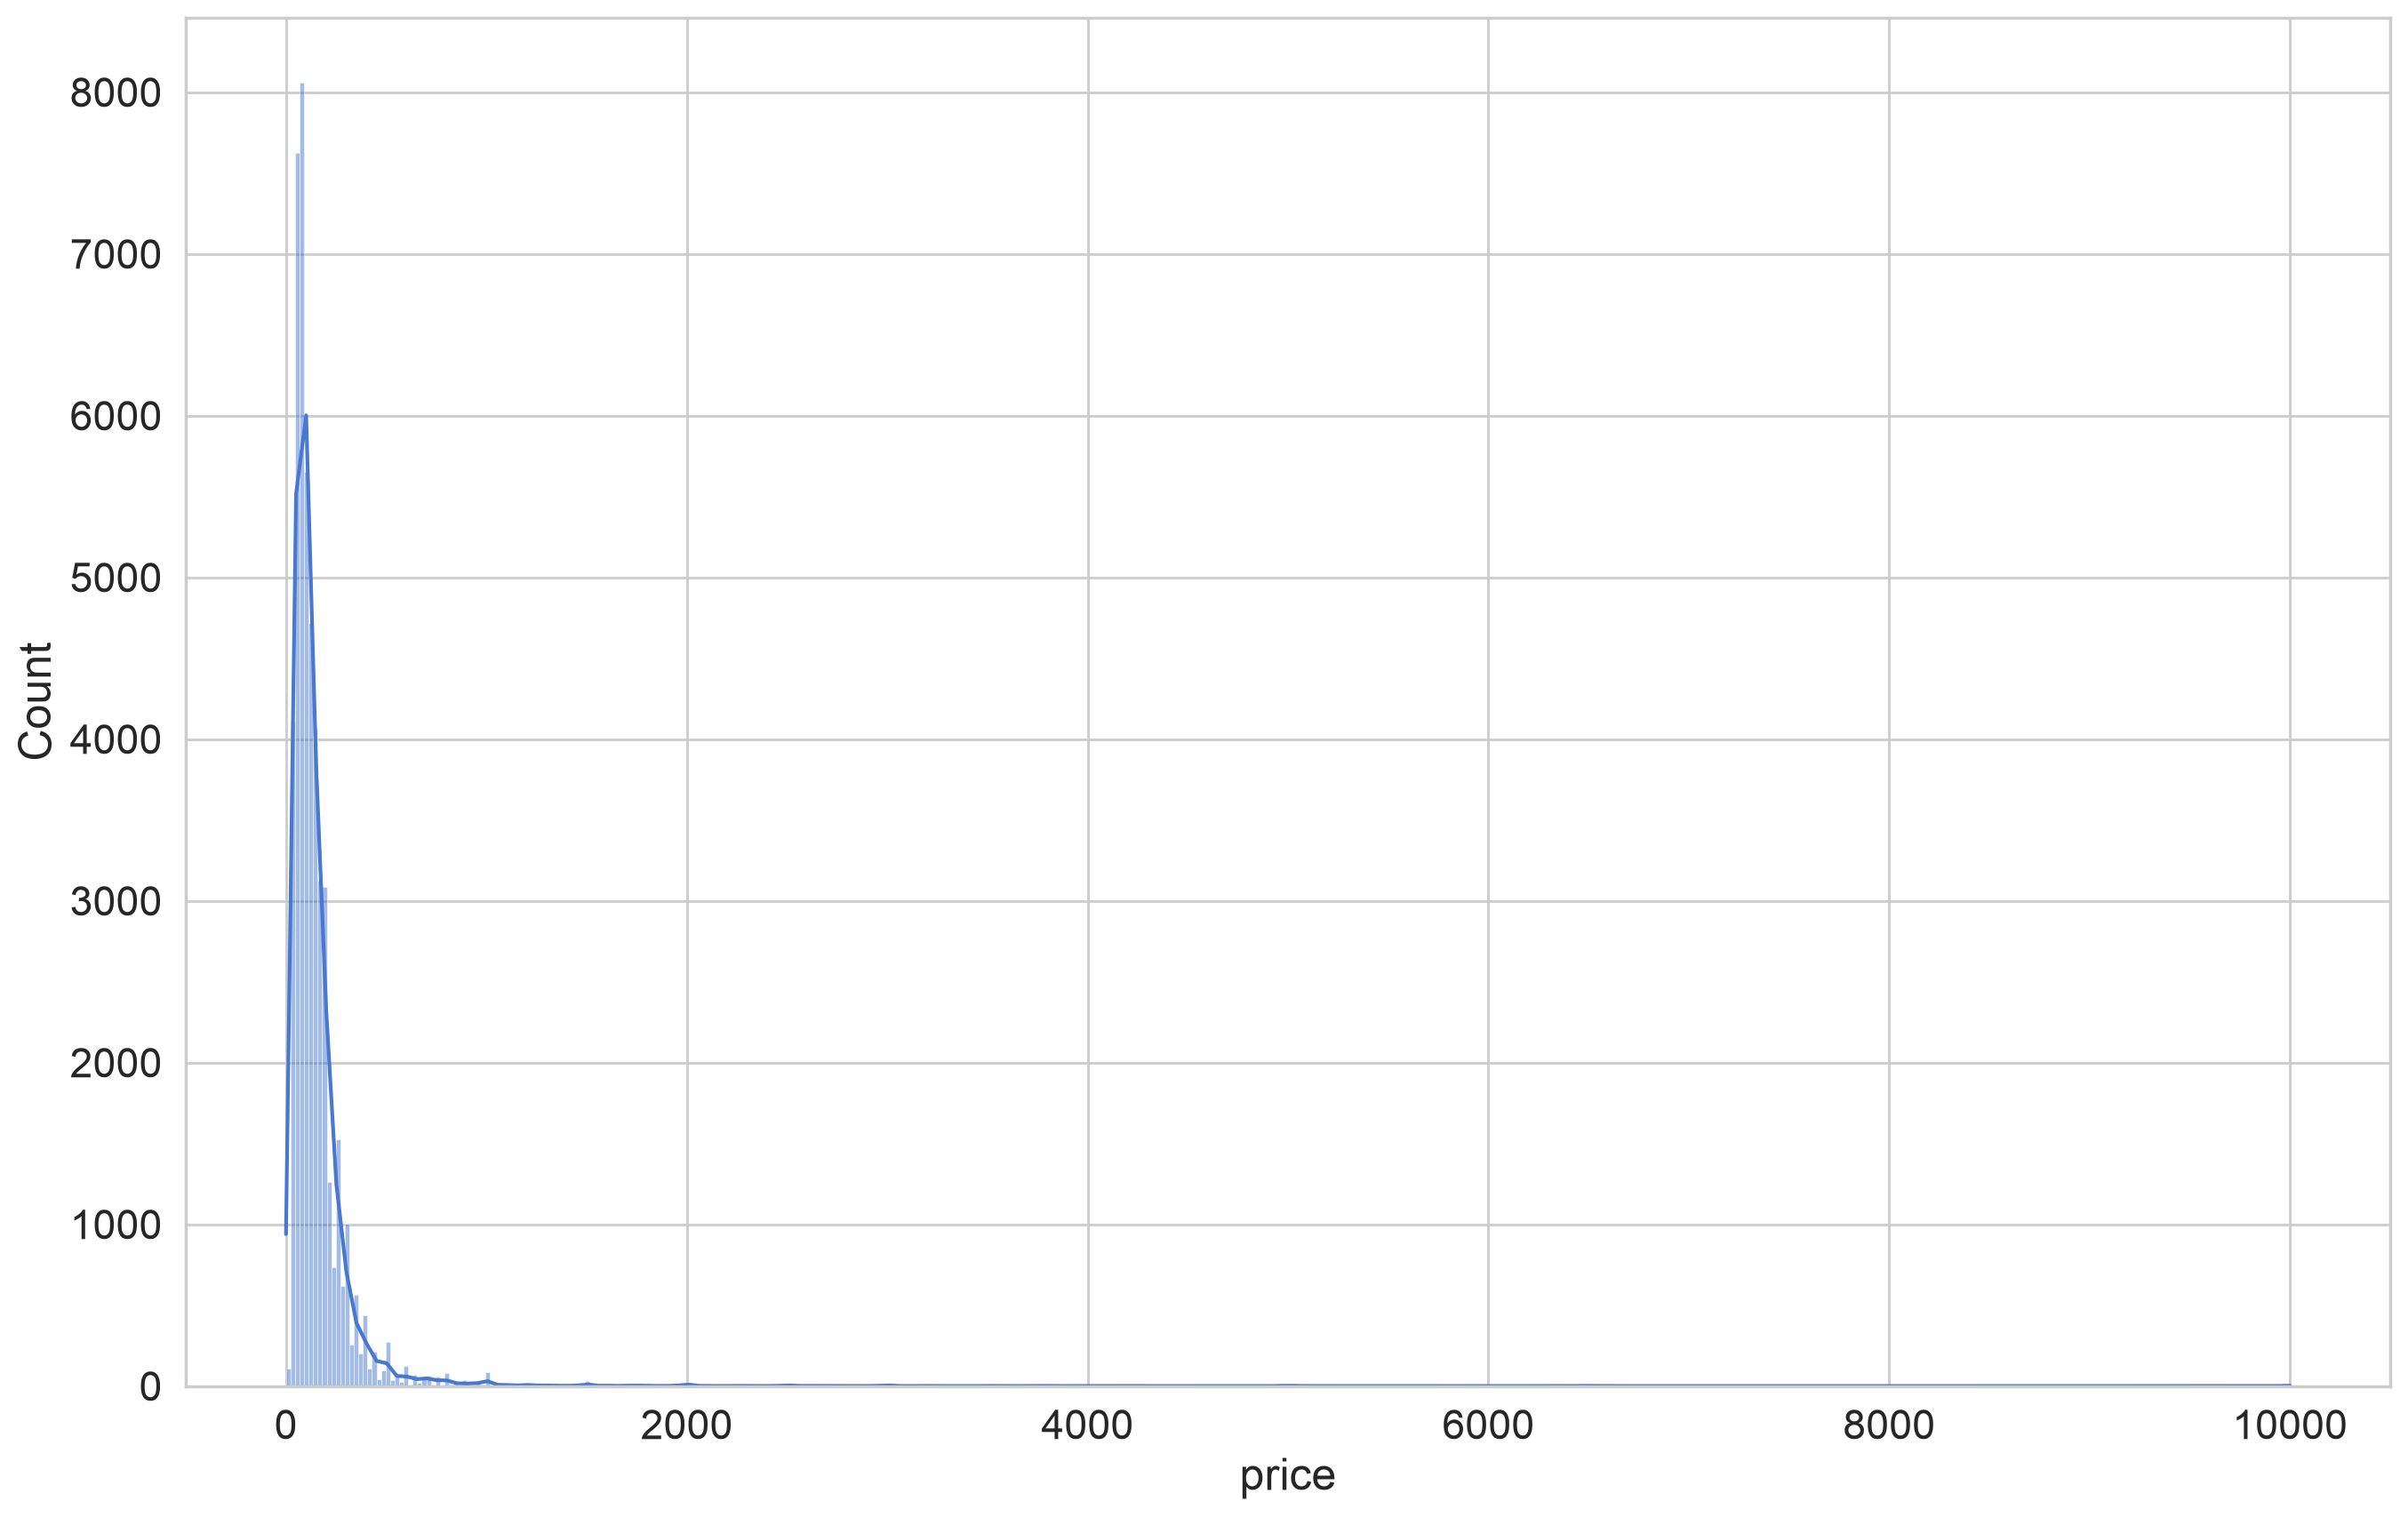

In [21]:
sns.histplot(df['price'], kde= True)

/var/folders/sq/tx7yrpx14j9ff8_clmn3gd6w0000gn/T/ipykernel_1485/1601044293.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(df.price))


<Axes: xlabel='price', ylabel='Density'>

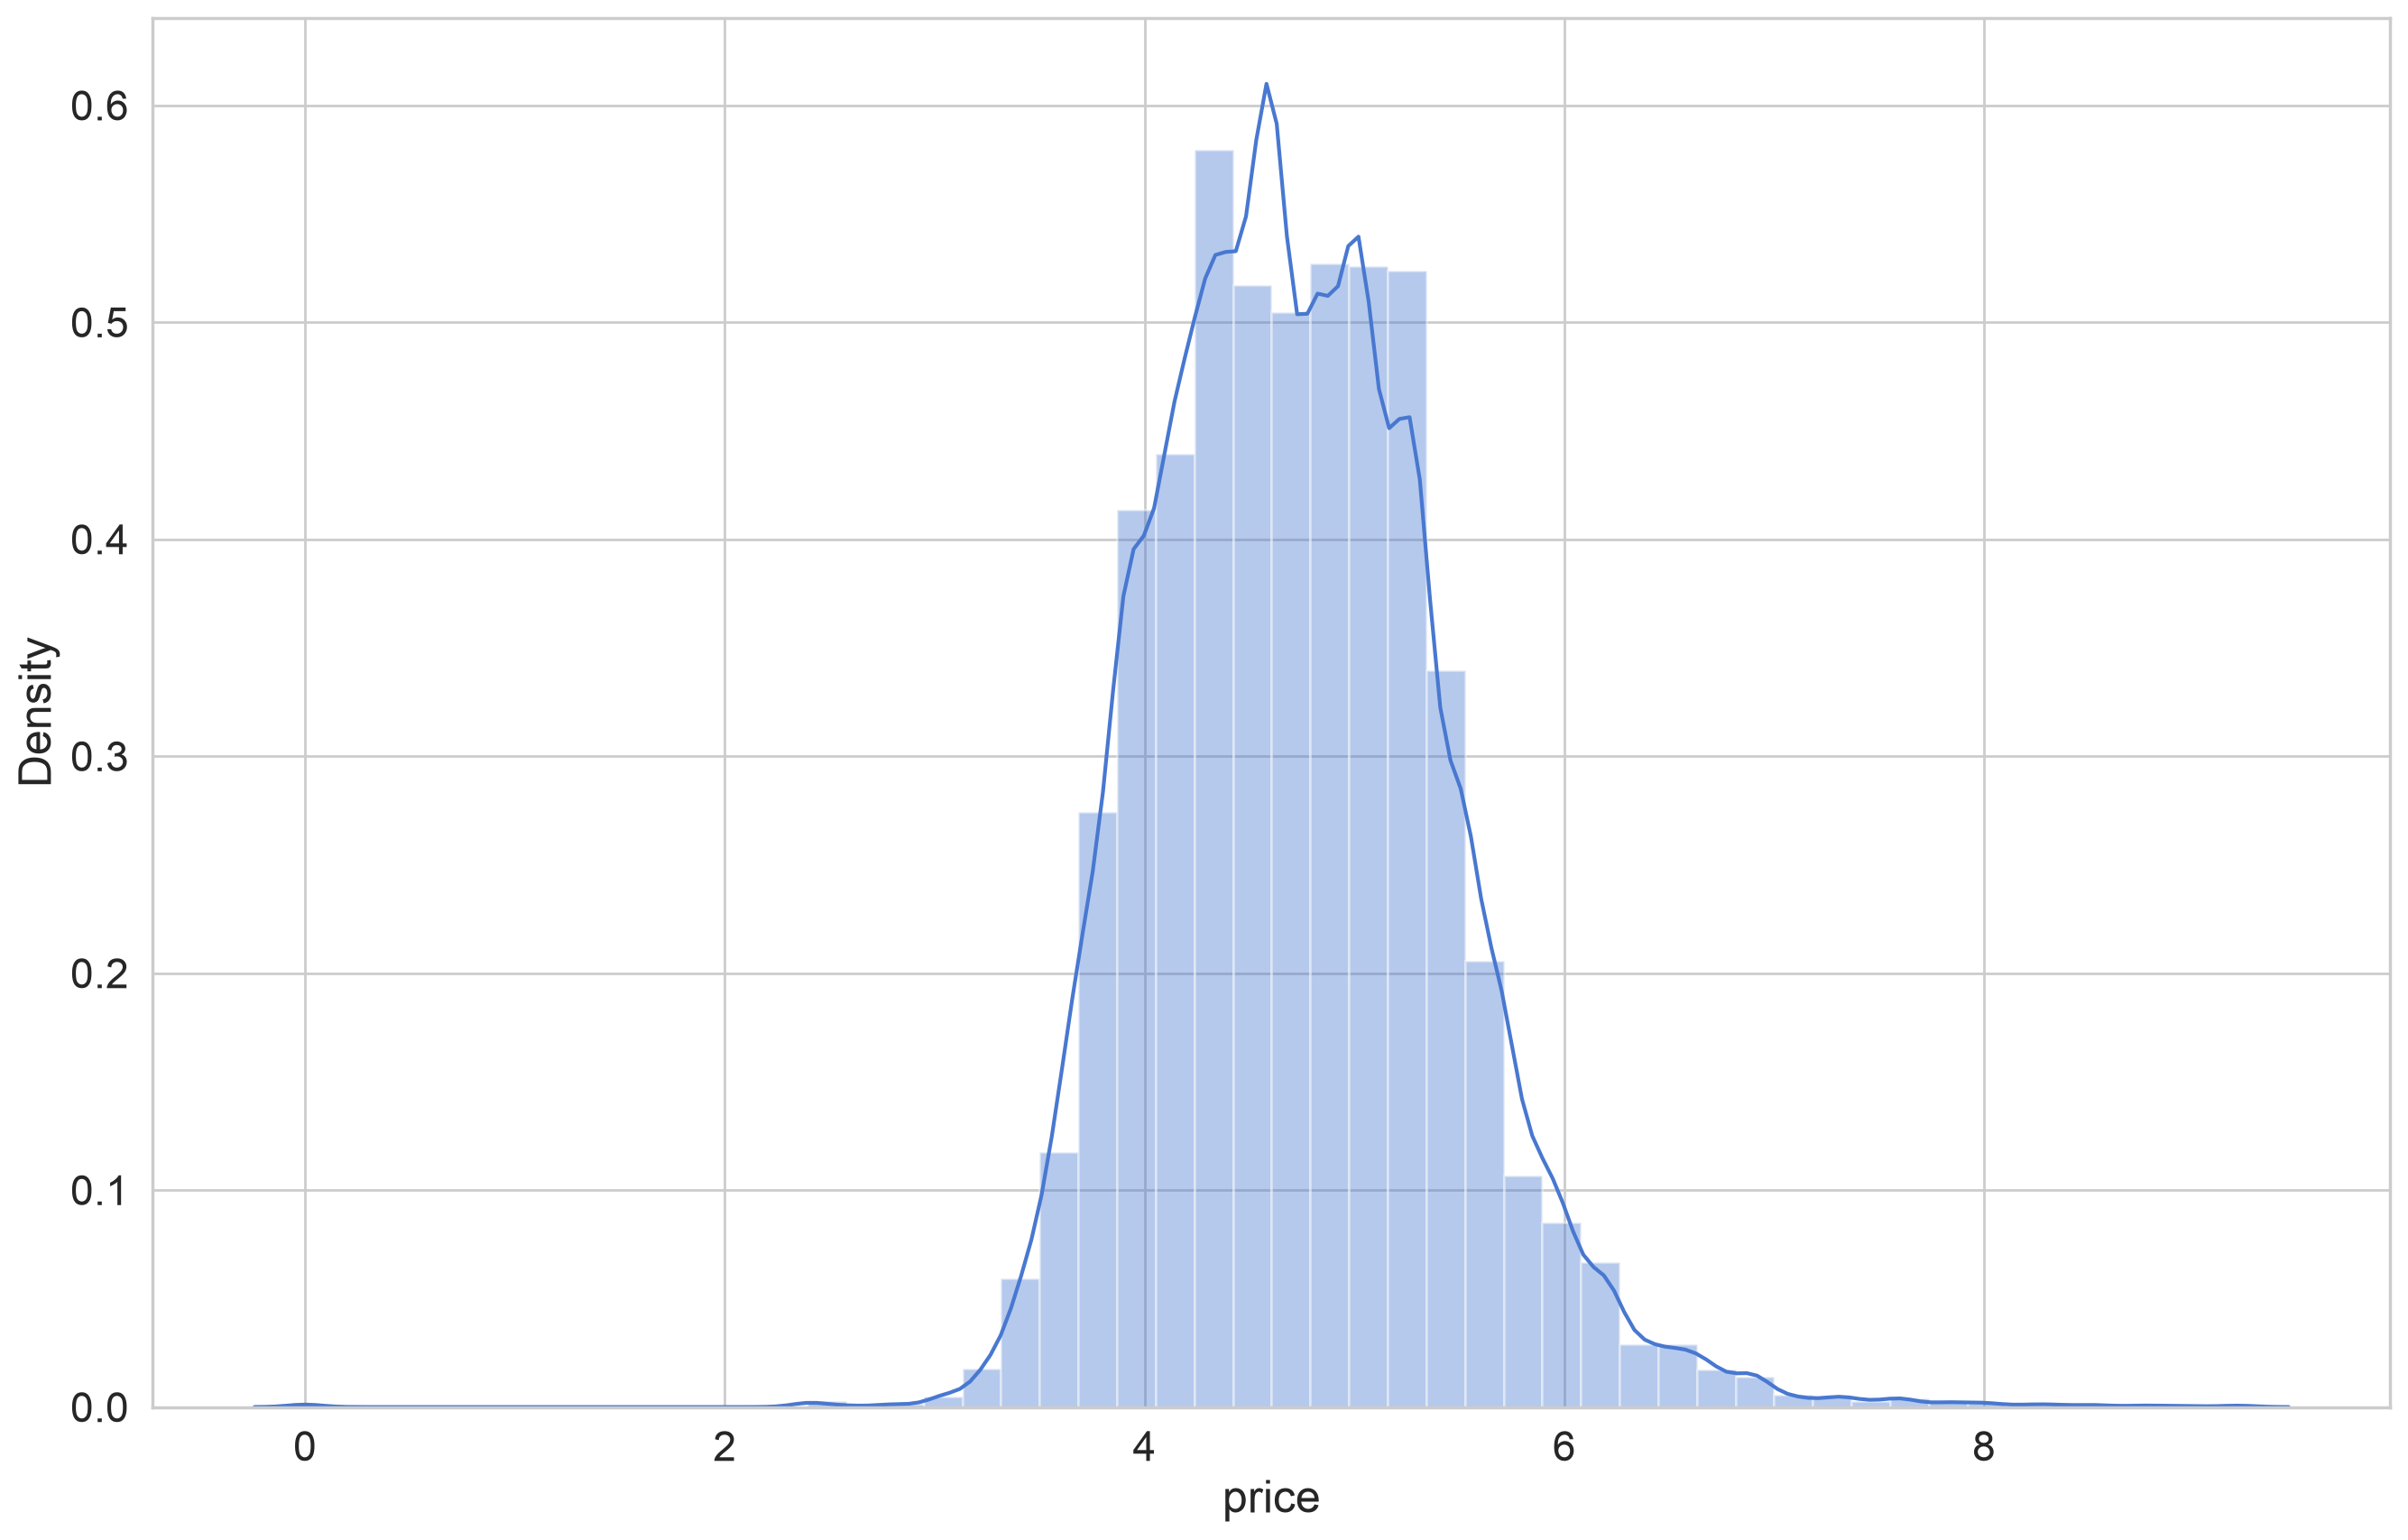

In [22]:
sns.distplot(np.log1p(df.price))

<Axes: xlabel='room_type', ylabel='count'>

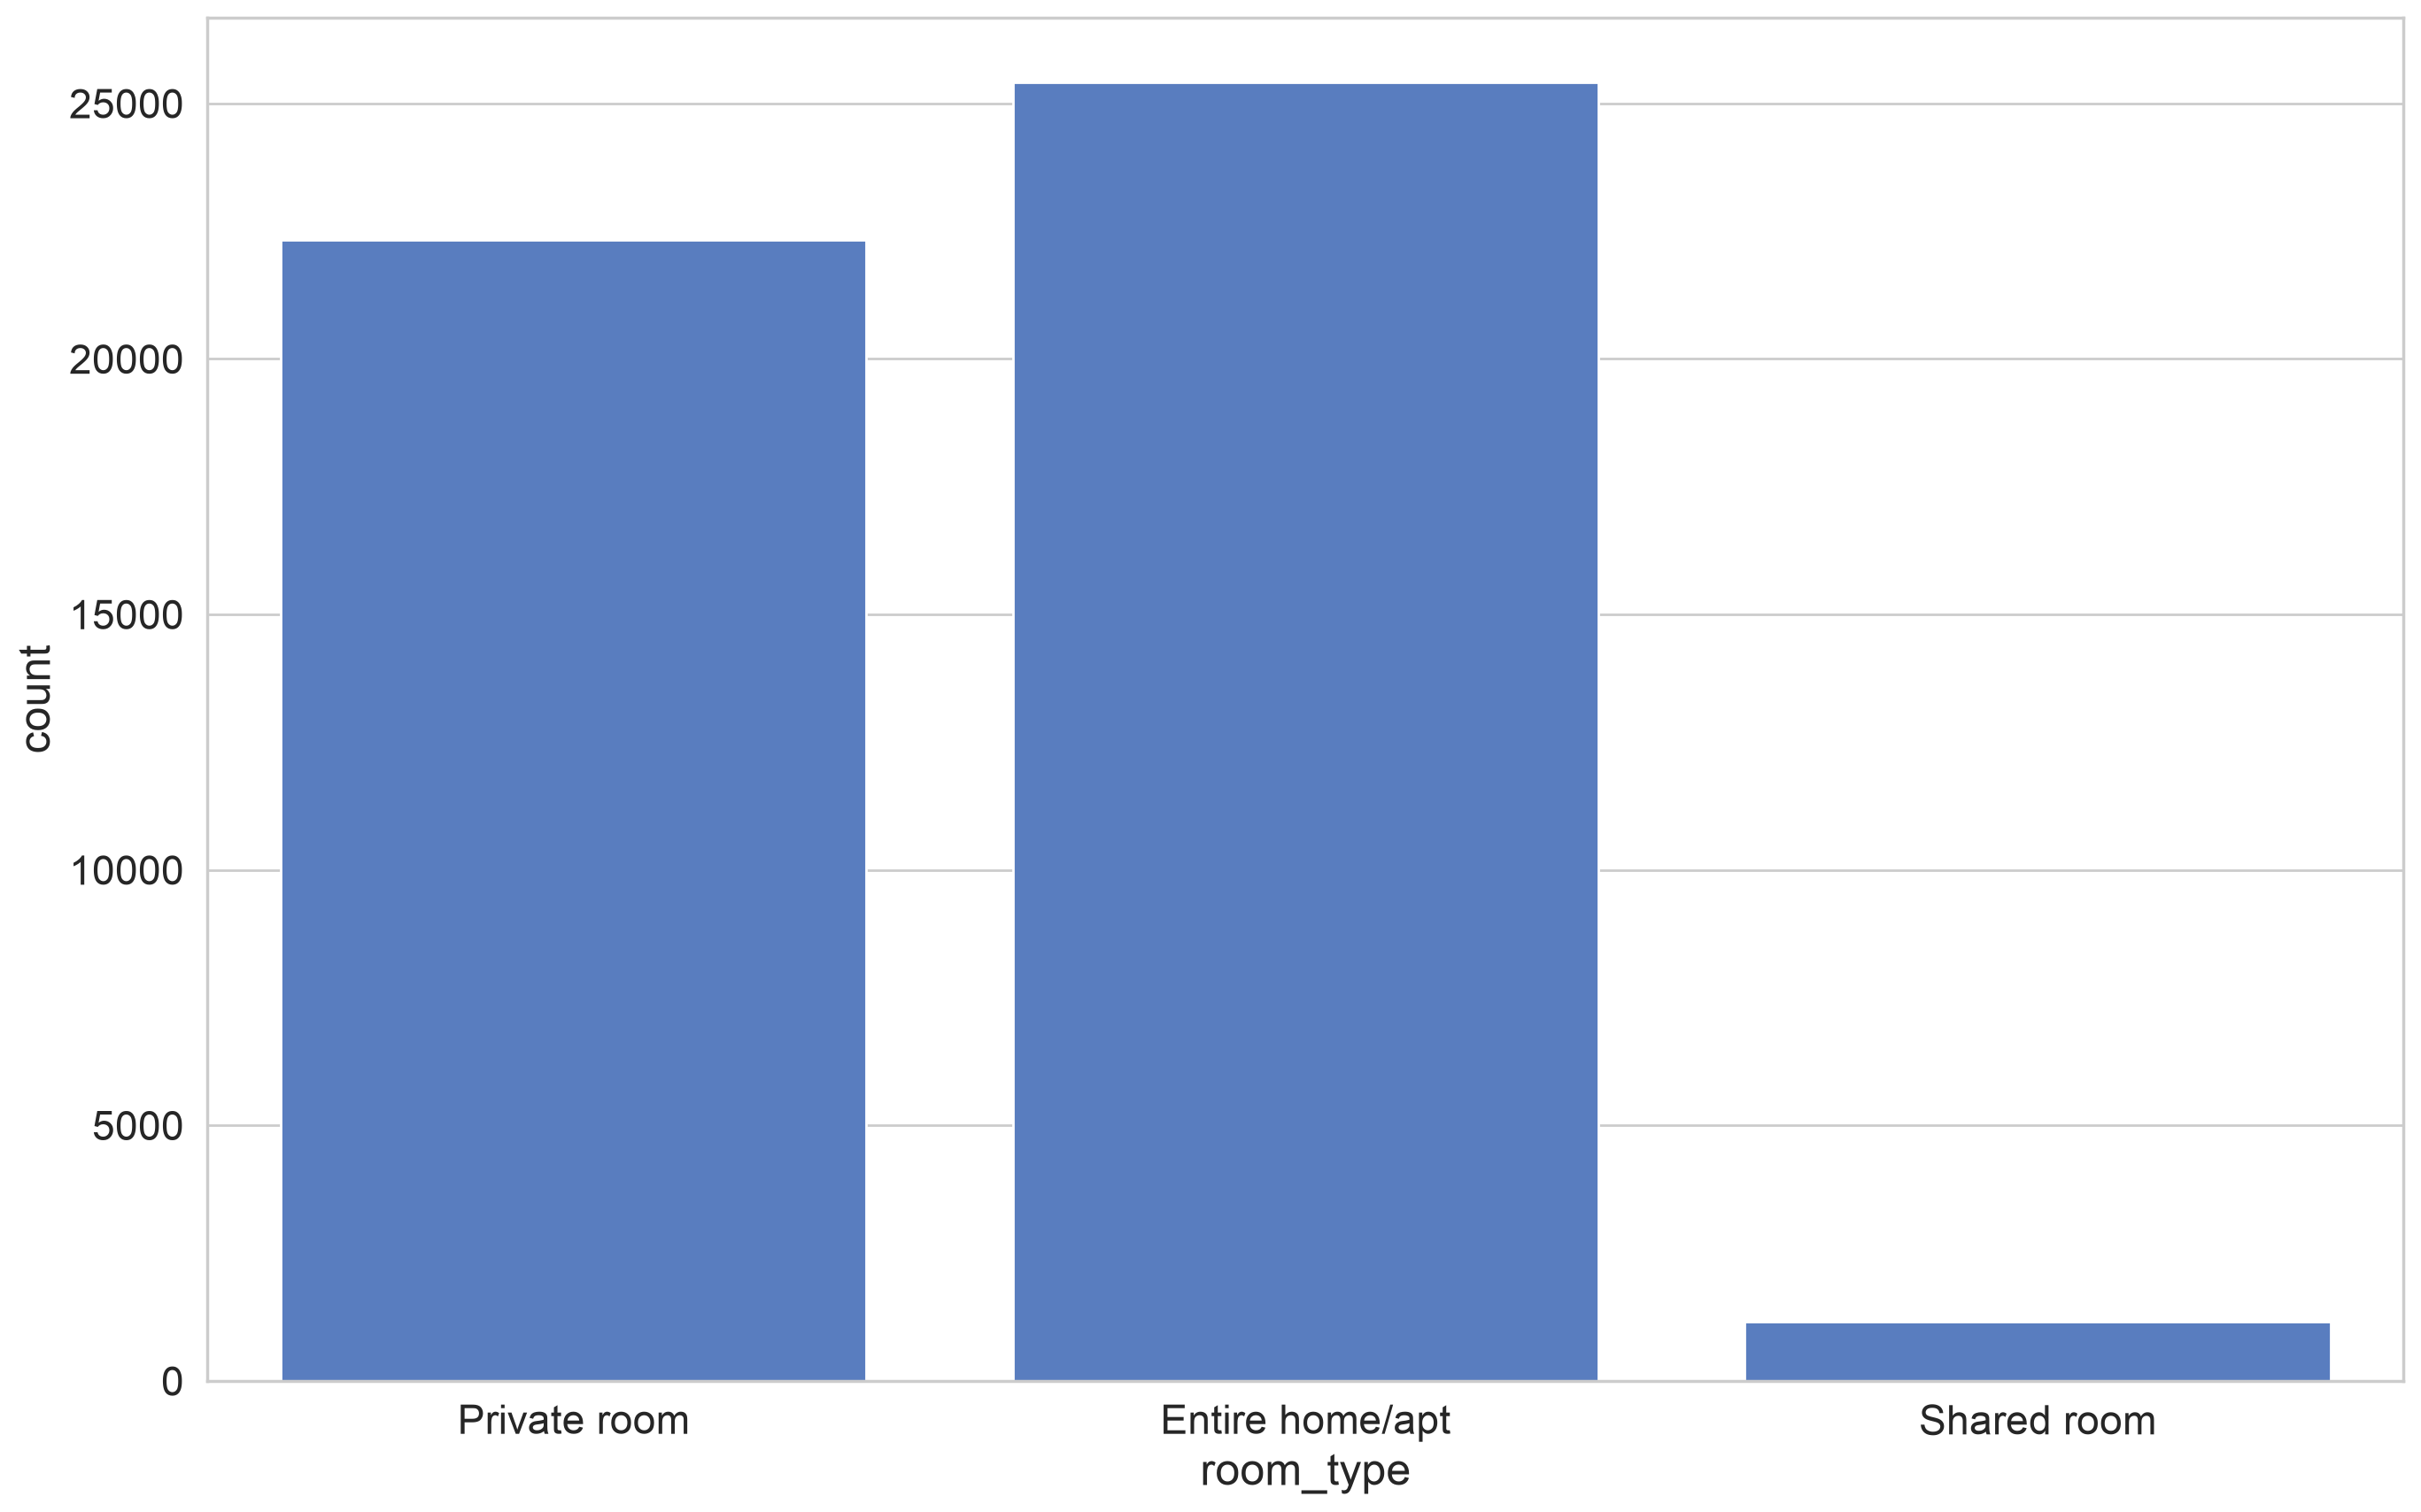

In [23]:
sns.countplot(x="room_type",data= df)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

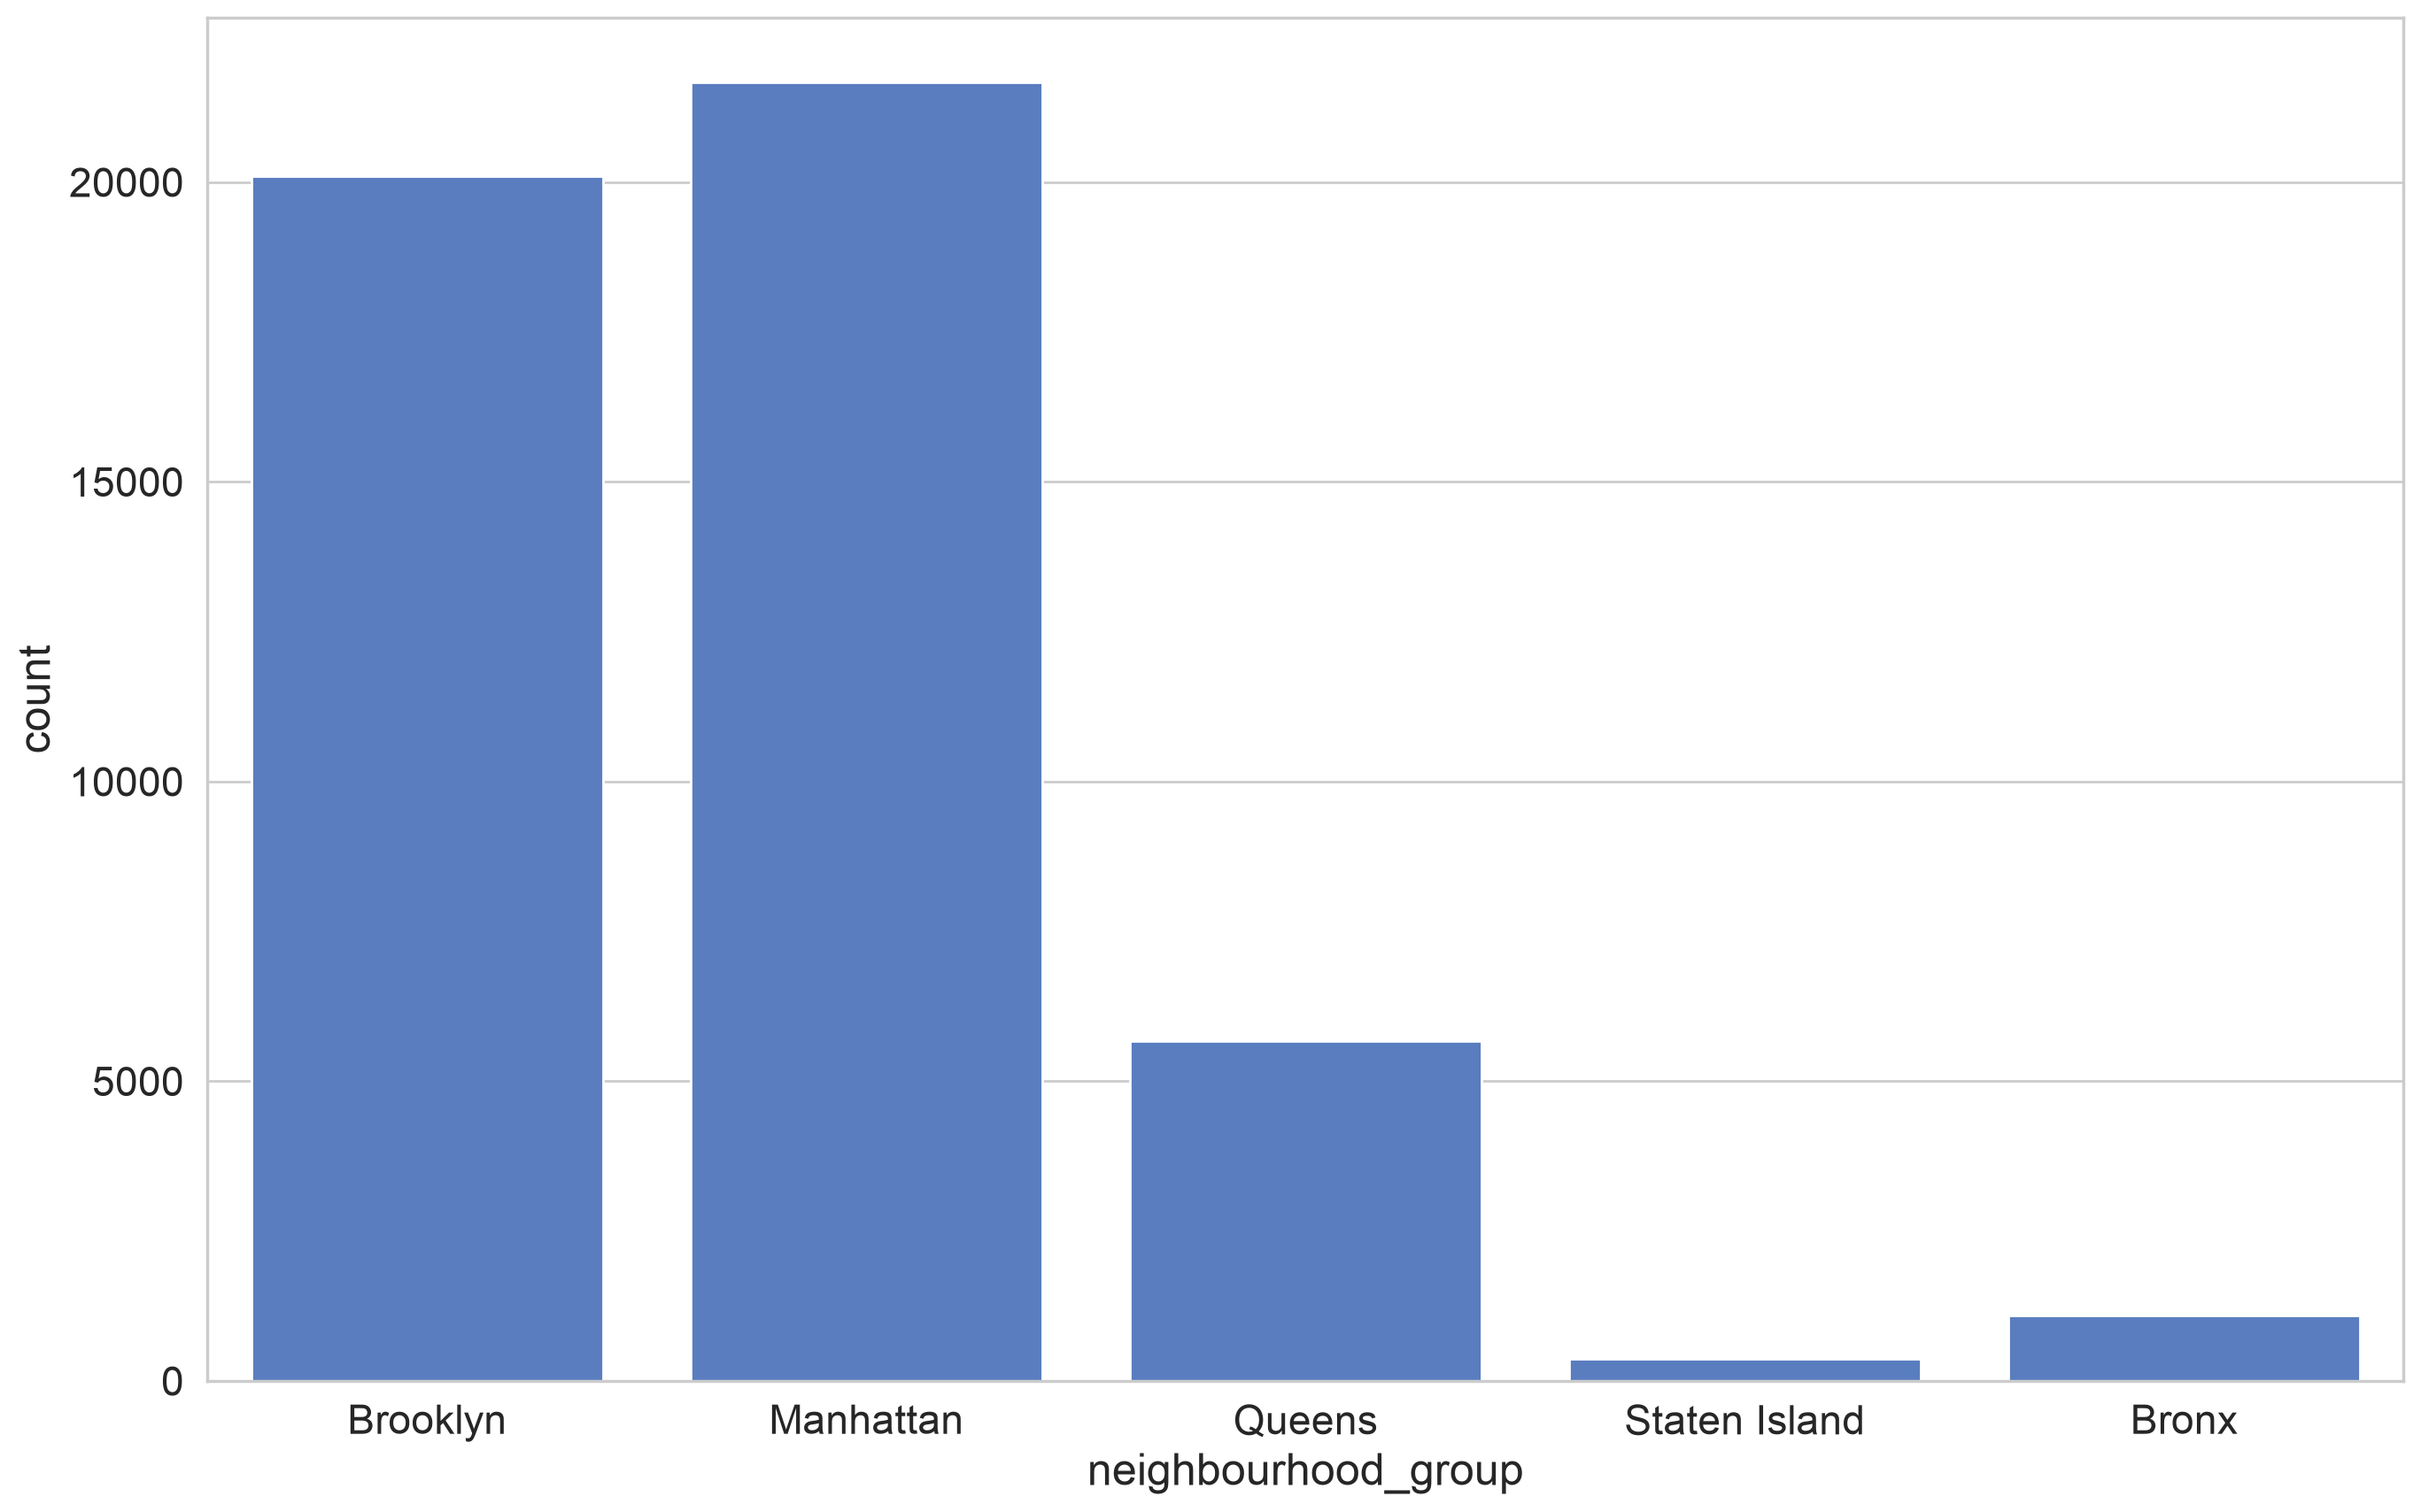

In [24]:
sns.countplot(x='neighbourhood_group', data= df)

/var/folders/sq/tx7yrpx14j9ff8_clmn3gd6w0000gn/T/ipykernel_1485/1662254443.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.number_of_reviews)


<Axes: xlabel='number_of_reviews', ylabel='Density'>

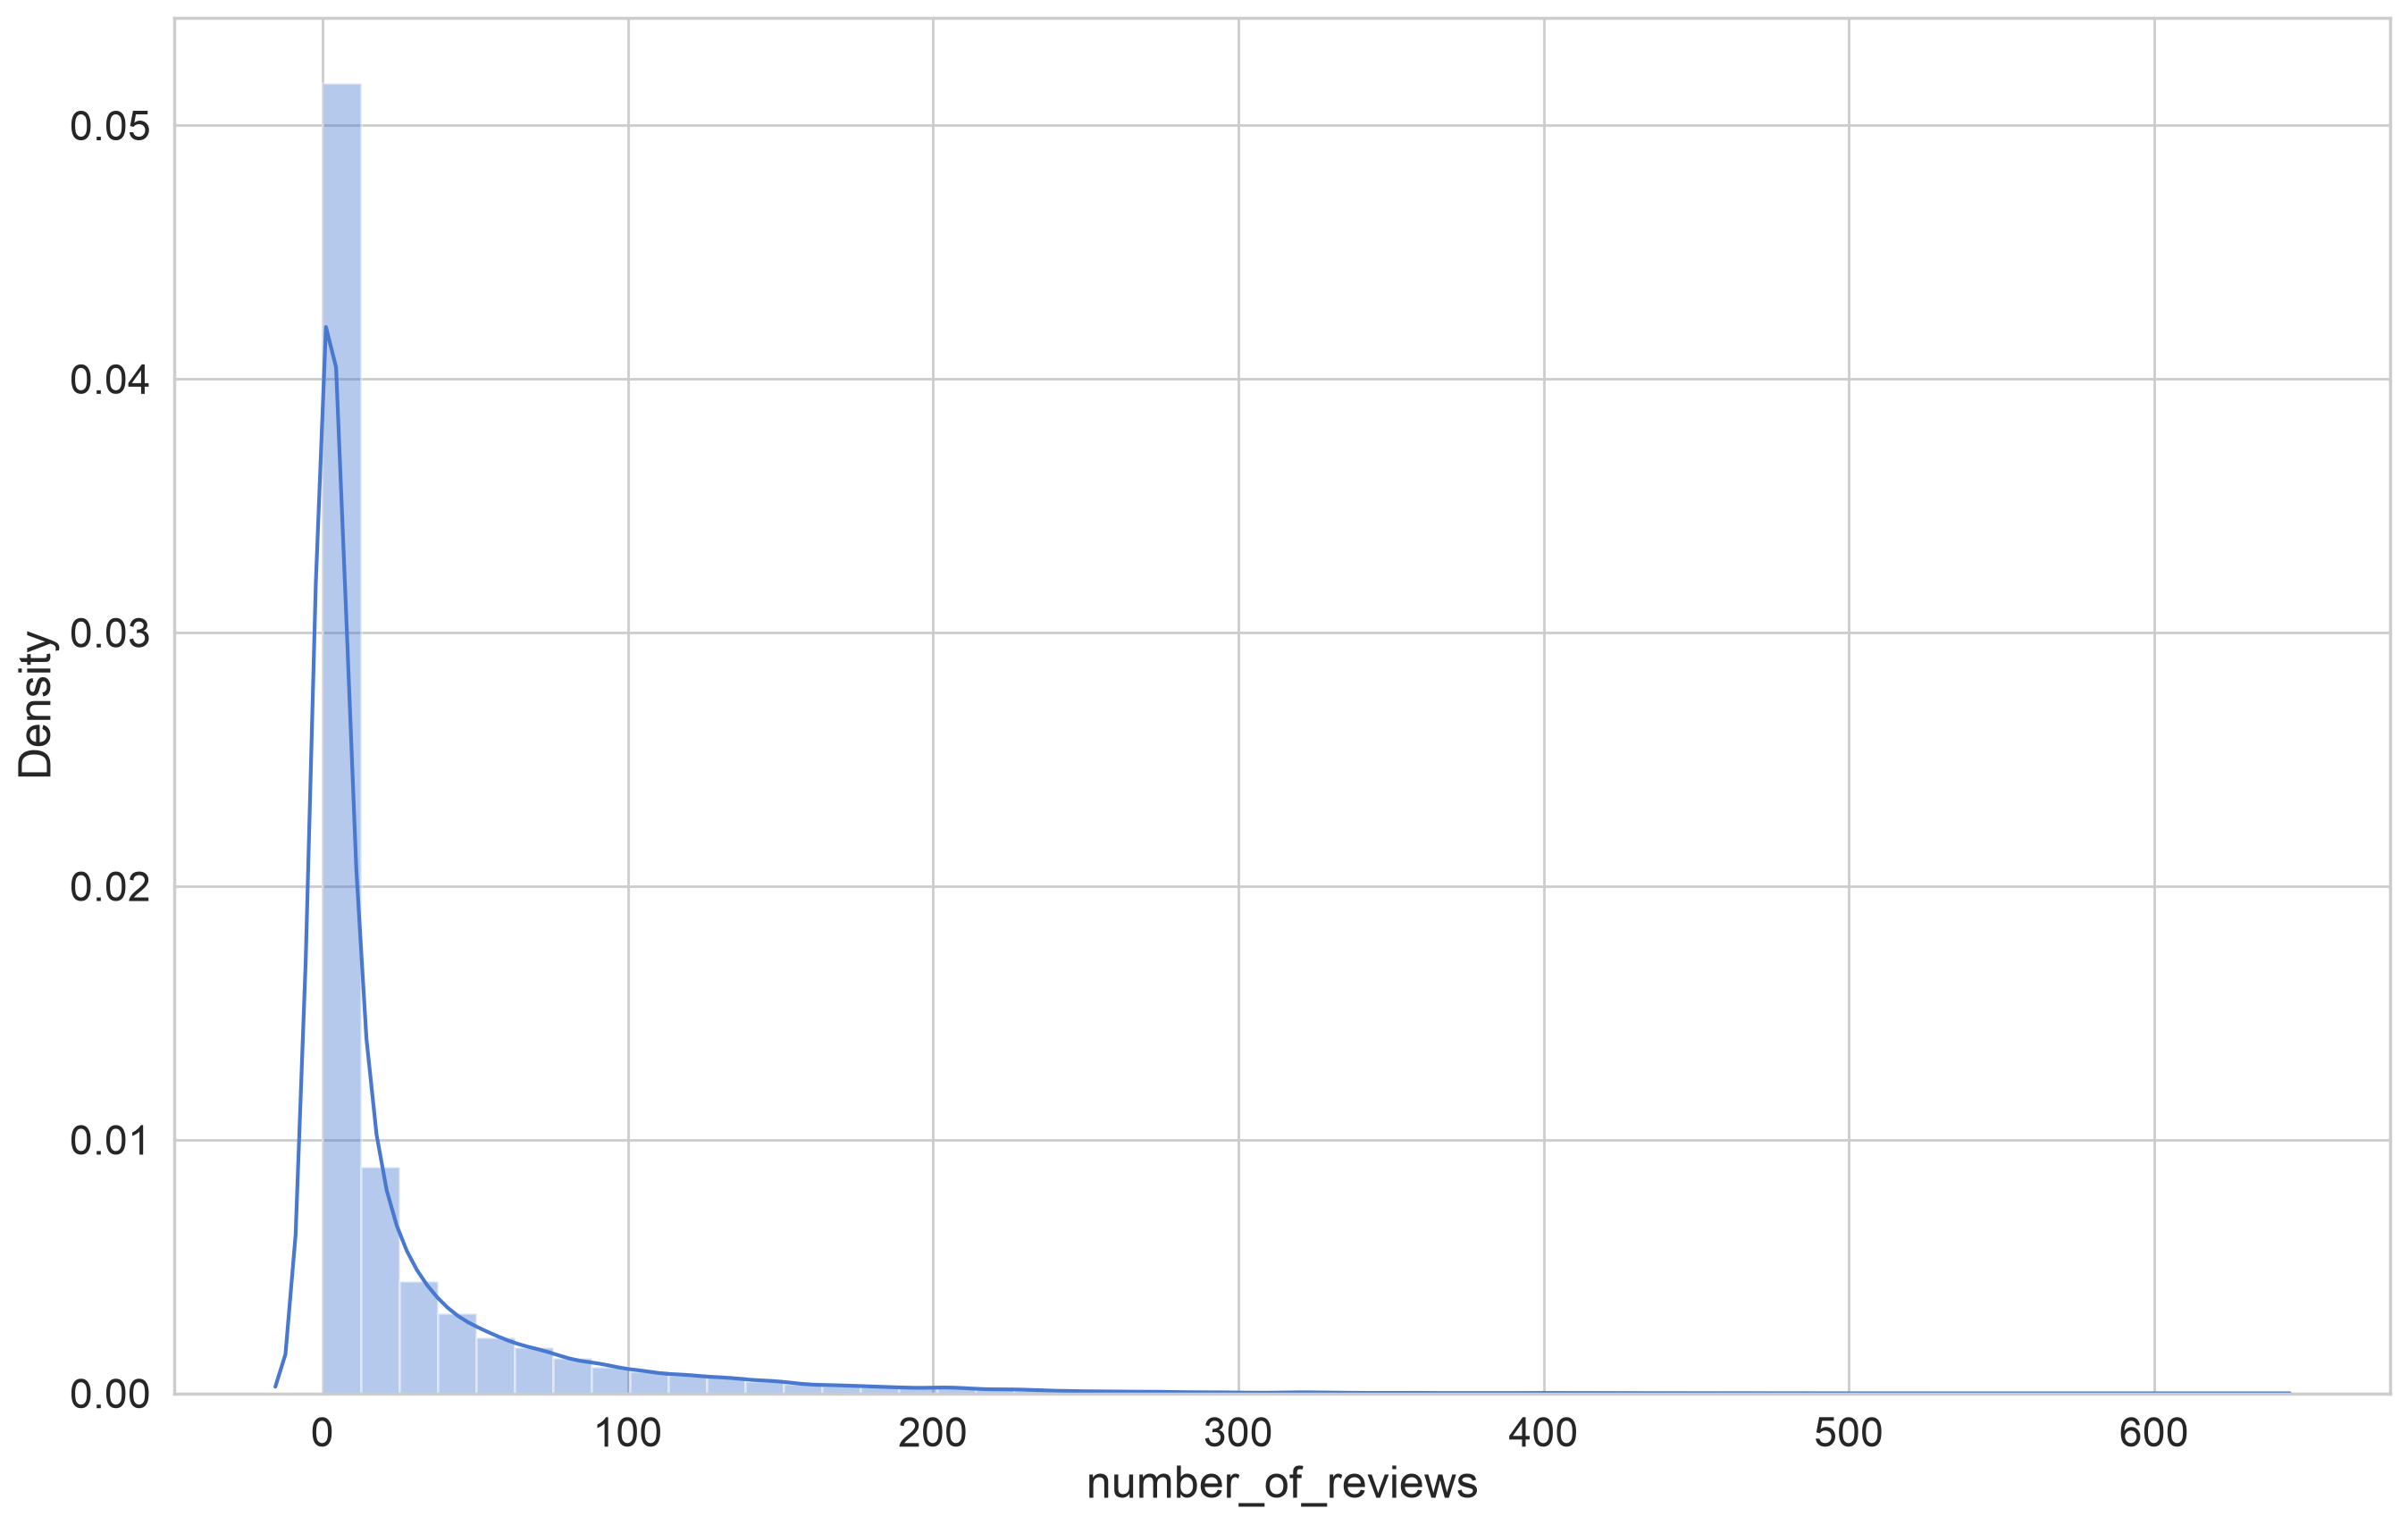

In [25]:
sns.distplot(df.number_of_reviews)

In [26]:
#Computing pearsons Correlations
corr_matrix = df.corr(numeric_only=True)
price_corr = corr_matrix['price']
price_corr.iloc[price_corr.abs().argsort()]

id                                0.010619
host_id                           0.015309
reviews_per_month                -0.030608
latitude                          0.033939
minimum_nights                    0.042799
number_of_reviews                -0.047954
calculated_host_listings_count    0.057472
availability_365                  0.081829
longitude                        -0.150019
price                             1.000000
Name: price, dtype: float64

# Prepare our Data

### Handle missing values
### Remove unnecessary columns
### Transform categorical to numerical
### Scale numerical fetaures

In [27]:
#Misiing values
missing = df.isnull().sum()

In [28]:
missing[missing>0].sort_values(ascending=False)

last_review          10052
reviews_per_month    10052
host_name               21
name                    16
dtype: int64

In [29]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [30]:
#droping features
df = df.drop(['id', 'name', 'host_id', 'host_name','neighbourhood','last_review','reviews_per_month'], axis=1)

In [31]:
df.shape

(48895, 9)

In [32]:
X = df.drop('price',axis=1)
y= np.log1p(df.price.values)

In [ ]:
#Feature Scaling
## we do MinMaxScaler Normalization and scale features in range 0-1 range. 